In [1]:
# specify a PYFILES path that contains the folder LFEAnalysis with this package
PYFILES='/Users/jessicahawthorne/PYFILES'

# and specify a data directory that contains all the LFE data
data_directory='/Users/jessicahawthorne/DATA/LFEAnalysis'

### Notebook 3. Downloading relevant seismic data

In order to analyse a set of LFEs, we need to have the relevant seismic data.  This notebook gives one way to download data via an FDSN client, using obspy's data retrieval functions.

The downloaded seismograms are saved in a simple 2-D array for each station and channel, with one row for each LFE interval.  These arrays will be later loaded and re-analysed.

Note that this approach to data retrieval is quite slow.  It can take a day to download signals from thousands of events for one family.  Since the download only has to be done once, I haven't tried to fix that, but it's an obvious target.

In [2]:
import numpy as np
import obspy
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(PYFILES))
import LFEAnalysis as lfeanalysis

### 1. Pick a region and a set of stations

First, we have to decide where to look.  Let's try looking at some LFEs along the Mexican subduction zone, near Guerrero.

There were a bunch of stations installed here from 2005 to 2007, in what was called the MASE array.  You can see their locations here: https://ds.iris.edu/gmap/#network=TO&maxlat=24.0096&maxlon=-97.6445&minlat=15.8768&minlon=-100.3362&drawingmode=box&planet=earth.

These data are stored by the IRIS data centre, and we can figure out the station names and channels by querying the data server.



In [3]:
# this line creates a shortcut to the function obspy.clients.fdsn.client.Client
from obspy.clients.fdsn.client import Client

# and this line calls the function Client to establish a connection to IRIS.
# note you might also try "ORFEUS" or "GEOFON" if you were looking for data collected by Europeans, 
# though IRIS has lots of European data too
client = Client("IRIS")

In [10]:
# let's grab an inventory of stations
# note that here we specify channels of the form '?H?', so we get seismic data
# this is only a subset of the MASE network
inv=client.get_stations(minlongitude=-101,maxlongitude=-97.6,
                        minlatitude=17.5,maxlatitude=18.7,
                        network='TO',channel='HH?',
                        level='channel',includeavailability=True)

23


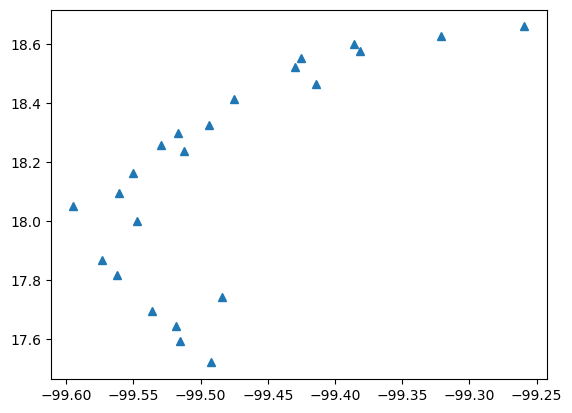

In [11]:
lons = [invi.longitude for invi in inv[0]]
lats = [invi.latitude for invi in inv[0]]
plt.plot(lons,lats,marker='^',linestyle='none');
print(len(lons))

In [4]:
# the inventory is indexed first by network (we've asked only for TO)
# then by station, then by channel

# we could look at the stations in just one network
print(inv[0])

Network TO (Tectonic Observatory - MASE, VEOX , PeruSE, CCSE (MASE, VEOX, PERUSE, CCSE))
	Station Count: 101/340 (Selected/Total)
	2004-01-01T00:00:00.000000Z - --
	Access: open
	Contains:
		Stations (101):
			TO.ACAH (MASE station ACAH, , , )
			TO.ACAP (MASE station ACAP, , , )
			TO.AGBE (MASE station AGBE, , , )
			TO.AMAC (MASE station AMAC, , , )
			TO.AMAR (MASE station AMAR, , , )
			TO.APOT (MASE station APOT, , , )
			TO.ARBO (MASE station ARBO, , , )
			TO.ATLA (MASE station ATLA, , , )
			TO.ATOT (MASE station ATOT, , , )
			TO.BUCU (MASE station BUCU, , , )
			TO.CANT (MASE station CANT, , , )
			TO.CARR (MASE station CARR, , , )
			TO.CASA (MASE station CASA, , , )
			TO.CEME (MASE station CEME, , , )
			TO.CHIC (MASE station CHIC, , , )
			TO.CHIO (MASE station CHIO, , , )
			TO.CIEN (MASE station CIEN, , , )
			TO.CIRE (MASE station CIRE, , , )
			TO.CIRI (MASE station CIRI, , , )
			TO.COAC (MASE station COAC, , , )
			TO.CUCE (MASE station CUCE, , , )
			TO.CUNO (MASE

In [5]:
# and maybe the first station in that network
print(inv[0][0])

# and the first channel at the station
print(inv[0][0][0])

Station ACAH (MASE station ACAH, , , )
	Station Code: ACAH
	Channel Count: 6/6 (Selected/Total)
	2004-12-15T00:00:00.000000Z - 2007-06-09T00:00:00.000000Z
	Access: open 
	Latitude: 17.3621, Longitude: -99.4683, Elevation: 838.0 m
	Available Channels:
	    ..HH[ZNE]   100.0 Hz  2004-12-15 to 2007-06-09
	  .01.HH[ZNE]   100.0 Hz  2004-12-15 to 2007-06-09

Channel 'HHE', Location '' 
	Time range: 2004-12-15T00:00:00.000000Z - 2007-06-09T00:00:00.000000Z
	Latitude: 17.3621, Longitude: -99.4683, Elevation: 838.0 m, Local Depth: 0.0 m
	Azimuth: 90.00 degrees from north, clockwise
	Dip: 0.00 degrees down from horizontal
	Channel types: GEOPHYSICAL
	Sampling Rate: 100.00 Hz
	Sensor (Description): None (CMG-3T)
	Response information available


In [6]:
# for now, we just want a list of the available stations
stations=np.unique([stat.code for stat in inv[0]])
print(stations)

['ACAH' 'ACAP' 'AGBE' 'AMAC' 'AMAR' 'APOT' 'ARBO' 'ATLA' 'ATOT' 'BUCU'
 'CANT' 'CARR' 'CASA' 'CEME' 'CHIC' 'CHIO' 'CIEN' 'CIRE' 'CIRI' 'COAC'
 'CUCE' 'CUNO' 'ECID' 'EL30' 'EL40' 'ELBA' 'ELPA' 'ELPO' 'ESTA' 'HUEJ'
 'HUIT' 'IXCA' 'JIUT' 'KM67' 'MAXE' 'MAZA' 'MIMO' 'MIXC' 'MOJO' 'MOLA'
 'MULU' 'NOGA' 'OCOL' 'OCOT' 'PABL' 'PACH' 'PALM' 'PASU' 'PEMU' 'PETA'
 'PLAT' 'PLAY' 'PLLI' 'PLSA' 'PSIQ' 'PTCU' 'PTRP' 'PUIX' 'QUEM' 'RIVI'
 'RODE' 'SABI' 'SAFE' 'SAFR' 'SAGR' 'SALU' 'SAME' 'SAPA' 'SAPE' 'SATA'
 'SJVH' 'SNLU' 'SUPA' 'TECA' 'TEMI' 'TEMP' 'TEPE' 'TEPO' 'TIAG' 'TIAN'
 'TIBL' 'TICO' 'TIZA' 'TLAL' 'TOMA' 'TONA' 'TONI' 'TONN' 'TONO' 'TOSU'
 'UICA' 'VEGU' 'VENA' 'VEVI' 'VLAD' 'XALI' 'XALT' 'XOCH' 'XOLA' 'ZACA'
 'ZURI']


### 2. Read the regional LFE catalogue

Other researchers, particularly Frank et al (2014), have identified a number of LFEs during SSEs in Guerrero.  Our LFE analysis object has a function to read in Frank et al's catalogue: read_detection_info_guerrero.

So let's read them.

In [ ]:
# create an analysis object
lfeanalysis.reload_all(lfeanalysis)
lf=lfeanalysis.lfeanalyse(fnum=540,data_directory=data_directory,region='Guerrero')

# read the relevant detections
lf.read_detection_info()

[ 335  413  196 ...  879  811 1018]


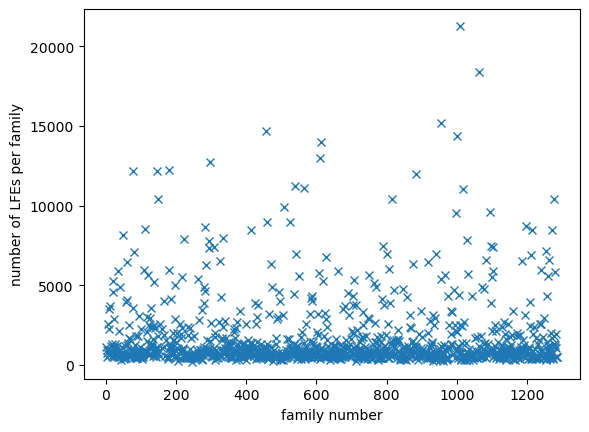

In [8]:
# if we want to see all the available families,
# it may be useful to read the whole catalog, not just a single family
tms,loc,dct=lfeanalysis.read_catalogues.read_frank2014(data_directory=data_directory)
iev=dct['Template_ID'].astype(int)

# the family of each LFE detection
print(iev)

# number of LFEs per family
nper=np.bincount(iev)
fnums=np.where(nper>0)[0]
nper=nper[fnums]
plt.plot(fnums,nper,linestyle='none',marker='x');
plt.xlabel('family number');
plt.ylabel('number of LFEs per family');

In [9]:
# check out the detections we have here for the family we're currently considering
print(lf.tms)

print('\nFamily {:d} has {:d} detected LFEs'.format(lf.fnum,lf.tms.size))

[UTCDateTime(2005, 1, 15, 2, 46, 16, 500000)
 UTCDateTime(2005, 1, 15, 2, 48, 15, 500000)
 UTCDateTime(2005, 1, 15, 3, 19, 56, 300000) ...
 UTCDateTime(2007, 4, 15, 12, 49, 25, 100000)
 UTCDateTime(2007, 4, 15, 17, 33, 21, 400000)
 UTCDateTime(2007, 4, 15, 18, 31, 57, 300000)]

Family 540 has 11261 detected LFEs


### 3. Select the stations to consider

The code will attempt to identify data for stations listed in lf.stns, so put the list of potential stations there.

In [10]:
# note the stations of interest, as identified via the IRIS datacentre
lf.stns=stations.copy()

### 4. Identify the channels for each of the available stations

We want the E, N, and Z components for each of these stations.  But seismic channels are usually labelled things like 'EH1', or 'HHN' rather than 'E', 'N', and 'Z'.  The function lf.identify_channels queries the FDSN server to identify stations that have at least three channels named 'EH?','HH?', or 'BH?'.

It may take a minute to run.

In [11]:
# identify the channels at the stations specified 
# for Guerrero, we know that the channels all start with H,
# so specify that
lf.identify_channels(cdes='H')


Identified channels for 101 of 101 stations


In [12]:
# we can now see which channels are available
print(lf.channels)

stn='ATOT'
print('\nThe channels for station {:s} are '.format(stn),lf.channels[stn])

{np.str_('ACAH'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('ACAP'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('AGBE'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('AMAC'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('AMAR'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('APOT'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('ARBO'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('ATLA'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('ATOT'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('BUCU'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CANT'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CARR'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CASA'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CEME'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CHIC'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CHIO'): array(['HHE', 'HHN', 'HHZ'], dtype='<U3'), np.str_('CIEN'): array(['HHE', 'HHN', '

The stations with available channels are retained in lf.stns, while others are discarded.  The next section will download seismic data at the stations in lf.stns.

In [13]:
# in case you want to make things go faster, uncomment the below to just retrieve seismic data from 10 stations
#lf.stns=lf.stns[0:10]
print('We will now attempt to retrieve data from {:d} stations'.format(lf.stns.size))

We will now attempt to retrieve data from 101 stations


### 5. Try to start downloading the data

We'll use an FDSN client to retrieve data from the IRIS data centre.  The code is set up to download intervals of data that include the LFE detection times.  Each interval is lf.tlen seconds long, and the detection times are a quarter of the way through the interval.

The code actually downloads a slightly longer interval, adding 10 seconds on either end.  It removes a trend and the instrument response, and then saves the data to the desired directory.  

In [14]:
# specify the duration of the intervals to download: here 80 s
lf.tlen=80.
print('Downloading and processing {:0.0f}-s data segments'.format(lf.tlen))

# these data will be saved in a subdirectory of lf.data_directory:
print('\nThe data will be saved in directory {:s}'.format(lf.directory()))


The data will be saved in directory /Users/jessicahawthorne/DATA/LFEAnalysis/Guerrero/Family540


In [15]:
# specify a pre-filter and a water level
# these will be applied in the response correction
pre_filt=(1/15.,1/5.,30,40)
water_level=100.

# download the data for the first 4 events
lf.download_data(max_events=4,pre_filt=pre_filt,water_level=water_level)

# these data should be saved in directory lf.directory()

ONLY DOWNLOADING THE FIRST 4 EVENTS


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


Writing to file and continuing


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


In [16]:
lfeanalysis.reload_all(lfeanalysis)

### 5. Check that the data retrieval is okay

We can now read in the data from these four events and see how things are looking.

In [17]:
# create a new analysis object with the same family
# this uses the default data directory---you may need to change it as above
lf2=lfeanalysis.lfeanalyse(fnum=540,region='Guerrero')

In [18]:
# read detection info and templates                                                             
lf2.read_detection_info()

In [24]:
# read the data that we downloaded in the last section                                               
lf2.read_data()

In [25]:
# the data are saved in a dictionary of 2-D arrays, with one entry for each station-channel pair
print('There are data for the following station.channel pairs:')
print(lf2.data.keys())

There are data for the following station.channel pairs:
dict_keys([np.str_('ACAH.HHE'), np.str_('ACAH.HHN'), np.str_('ACAH.HHZ'), np.str_('ACAP.HHE'), np.str_('ACAP.HHN'), np.str_('ACAP.HHZ'), np.str_('AGBE.HHE'), np.str_('AGBE.HHN'), np.str_('AGBE.HHZ'), np.str_('AMAC.HHE'), np.str_('AMAC.HHN'), np.str_('AMAC.HHZ'), np.str_('AMAR.HHE'), np.str_('AMAR.HHN'), np.str_('AMAR.HHZ'), np.str_('APOT.HHE'), np.str_('APOT.HHN'), np.str_('APOT.HHZ'), np.str_('ARBO.HHE'), np.str_('ARBO.HHN'), np.str_('ARBO.HHZ'), np.str_('ATLA.HHE'), np.str_('ATLA.HHN'), np.str_('ATLA.HHZ'), np.str_('ATOT.HHE'), np.str_('ATOT.HHN'), np.str_('ATOT.HHZ'), np.str_('BUCU.HHE'), np.str_('BUCU.HHN'), np.str_('BUCU.HHZ'), np.str_('CANT.HHE'), np.str_('CANT.HHN'), np.str_('CANT.HHZ'), np.str_('CARR.HHE'), np.str_('CARR.HHN'), np.str_('CARR.HHZ'), np.str_('CASA.HHE'), np.str_('CASA.HHN'), np.str_('CASA.HHZ'), np.str_('CEME.HHE'), np.str_('CEME.HHN'), np.str_('CEME.HHZ'), np.str_('CHIC.HHE'), np.str_('CHIC.HHN'), np.str_('

In [27]:
# let's look at the data for one station
ky=list(lf2.data.keys())[0]
stn,chn=ky.split('.')
print('The data for station {:s}, channel {:s} have shape '.format(stn,chn),lf2.data[ky].shape)
data = lf2.data[ky]

print('There are {:d} intervals saved for {:s}.{:s}'.format(data.shape[1],stn,chn))

The data for station ACAH, channel HHE have shape  (8000, 812)
There are 812 intervals saved for ACAH.HHE


These seismograms are for intervals  [0 1 2]


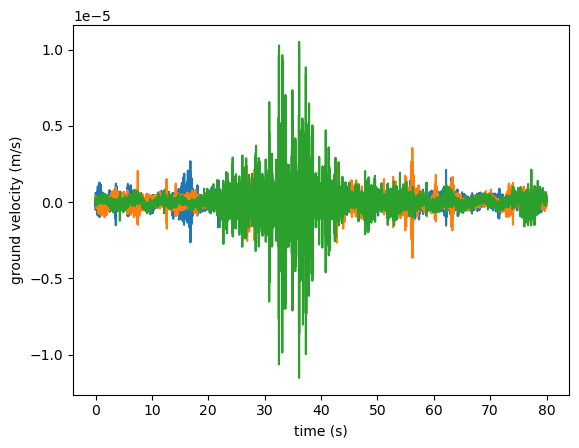

In [28]:
#The times of the observations can be inferred from the sampling rate.
times=np.arange(0,data.shape[0])/lf2.sampling_rate

# and we can plot the data from the first few LFE intervals
plt.plot(times,data[:,0:3]);
plt.ylabel('ground velocity (m/s)');
plt.xlabel('time (s)');

print('These seismograms are for intervals ',lf2.ev[ky][0:3])

Note that you're unlikely to see individual LFEs in these seismograms.  The data are normally too noisy for that.

### 6.  Download all of the data

If everything seems okay with the first four events, we can move on.

- First we delete everything in the data directory for this family: whatever is in lf.directory()

You can do this deletion manually or with the function clear_seismic_data below.  If you don't clear the directory, newly downloaded intervals will be appended to the existing intervals, and you may have multiples.

- Then we download everything

In [22]:
# delete everything in the data directory.
lf.clear_seismic_data()

In [23]:
# uncomment and run to download data for all the LFEs
#lf.download_data()

/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


...

/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] * m[:-1] + w[1:] * m[1:]) / (w[:-1] + w[1:])


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/clients/fdsn/client.py:909: UserWarning: 'TimeoutError' object has no attribute 'splitlines'
  warnings.warn(str(e))
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/clients/fdsn/client.py:909: UserWarning: 'URLError' object has no attribute 'splitlines'
  warnings.warn(str(e))
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/core/stream.py:3203: UserWarning: No matching response information found.
  warnings.warn(str(e))
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:142: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / np.clip(w, np.spacing(1), w.max())
/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/signal/interpolation.py:146: RuntimeWarning: invalid value encountered in multiply
  slope[1:-1] = (w[:-1] *

No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
Writing to file and continuing
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No data?
No dat